# Diffusion Models on Three Atoms with Noise-Level Parameter $\alpha$

Backward updates interpolate between deterministic ODE-like flow ($\alpha=0$)
and stochastic DDPM-style flow ($\alpha=1$). We visualize both trajectories.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
mu = np.array([[-1.2, -0.7], [1.1, -0.6], [0.1, 1.2]])
n_per = 80
x0 = np.repeat(mu, n_per, axis=0)
T = 120
beta = np.linspace(0.001, 0.045, T)
alpha_t = 1 - beta
abar = np.cumprod(alpha_t)

def score_mixture(x, t):
    a = np.sqrt(abar[t]); var = 1 - abar[t] + 1e-12
    means = a * mu
    diff = x[:, None, :] - means[None, :, :]
    logp = -0.5*np.sum(diff**2, axis=2)/var
    m = logp.max(axis=1, keepdims=True)
    w = np.exp(logp - m); w /= w.sum(axis=1, keepdims=True)
    return -np.sum(w[:, :, None]*diff, axis=1)/var

def run(alpha_noise=1.0):
    xf = x0.copy(); fwd = [xf.copy()]
    for t in range(T):
        xf = np.sqrt(alpha_t[t])*xf + np.sqrt(beta[t])*rng.normal(size=xf.shape)
        if t in [20, 60, 119]:
            fwd.append(xf.copy())
    xb = rng.normal(size=x0.shape); bwd = [xb.copy()]
    for t in range(T-1, -1, -1):
        s = score_mixture(xb, t)
        drift = (xb + beta[t]*s)/np.sqrt(alpha_t[t])
        noise = np.sqrt(beta[t]) * rng.normal(size=xb.shape)
        xb = drift + alpha_noise * noise
        if t in [80, 40, 0]:
            bwd.append(xb.copy())
    return fwd, bwd


## Static comparison for alpha=0 and alpha=1


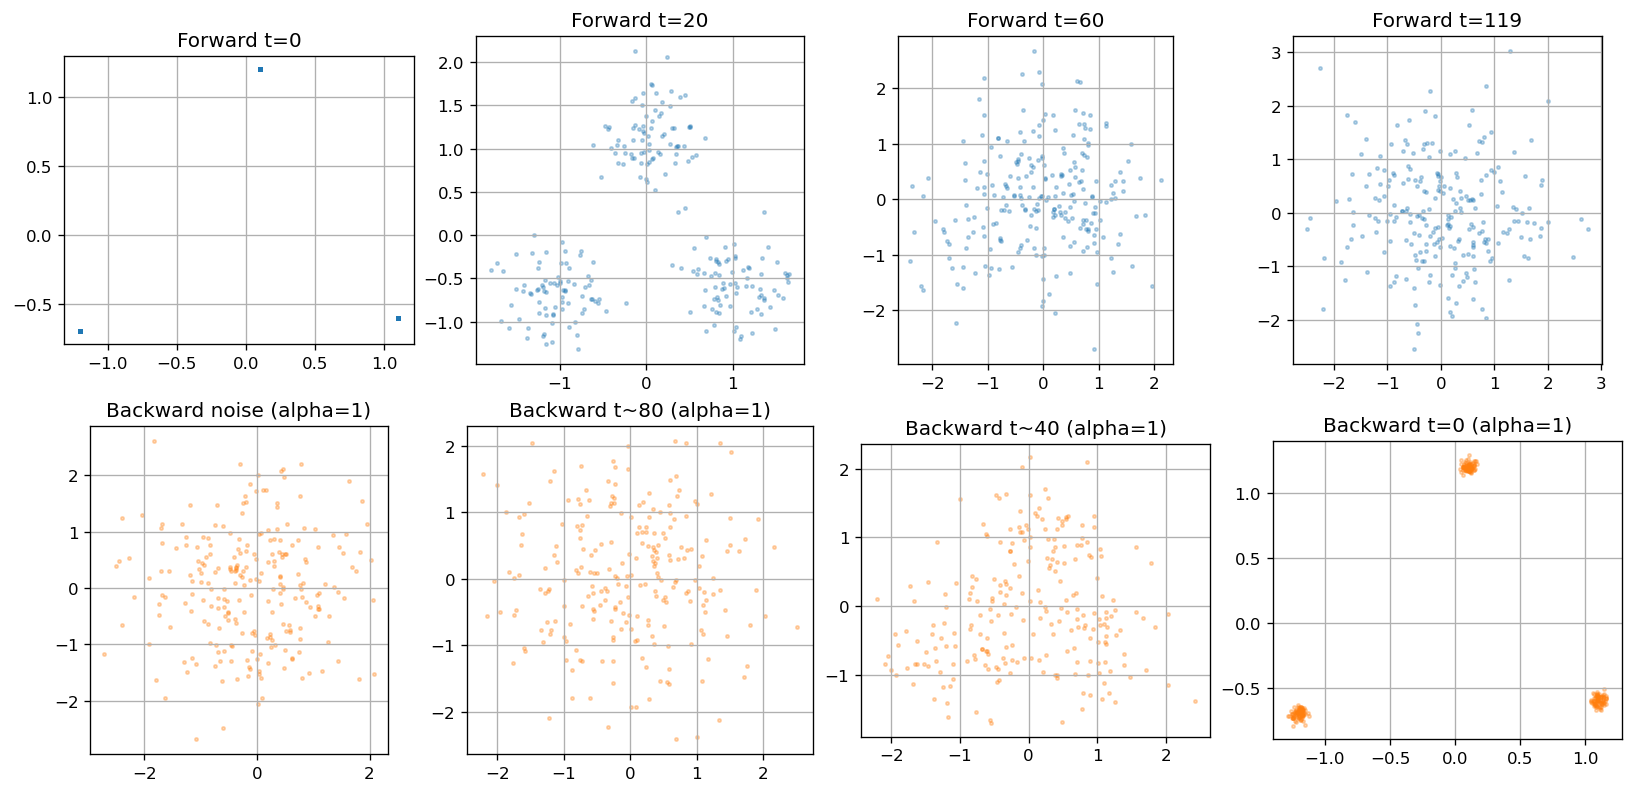

In [2]:
fwd0, bwd0 = run(0.0)
fwd1, bwd1 = run(1.0)
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.5), constrained_layout=True)
for ax, P, t in zip(axes[0], fwd1, [0, 20, 60, 119]):
    ax.scatter(P[:,0], P[:,1], s=4, alpha=0.3)
    ax.set_title(f"Forward t={t}")
    ax.set_aspect("equal")
for ax, P, t in zip(axes[1], bwd1, ['noise', 't~80', 't~40', 't=0']):
    ax.scatter(P[:,0], P[:,1], s=4, alpha=0.3, color='tab:orange')
    ax.set_title(f"Backward {t} (alpha=1)")
    ax.set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive alpha slider
